## Forward Propagation and Backpropagation using TensorFlow/Keras

To implement a Multilayer Perceptron (MLP) using TensorFlow/Keras for the Iris dataset and study the effect of different learning rates and epochs on model performance.

Import Libraries

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

NumPy → Numerical operations </br>
Pandas → Dataset handling </br>
Matplotlib → Graphs </br>
sklearn → Dataset & preprocessing </br>
TensorFlow/Keras → Neural Network </br>

Load Dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (150, 4)
Target Shape : (150,)


Explore Dataset

In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["Species"] = y

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Display information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


Statistics

In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Check target classes

In [7]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

<b>This helps us understand</b>

<li>Dataset size
<li>Data types
<li>Distribution
<li>Missing values
<li>Class balance

Split Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

<b>Train | Test Split</b> </br>

80% Training

20% Testing

Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Neural Networks learn better when features have similar scales.

Build Neural Network

In [10]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

d:\TY Sem-I\Deep Learning\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


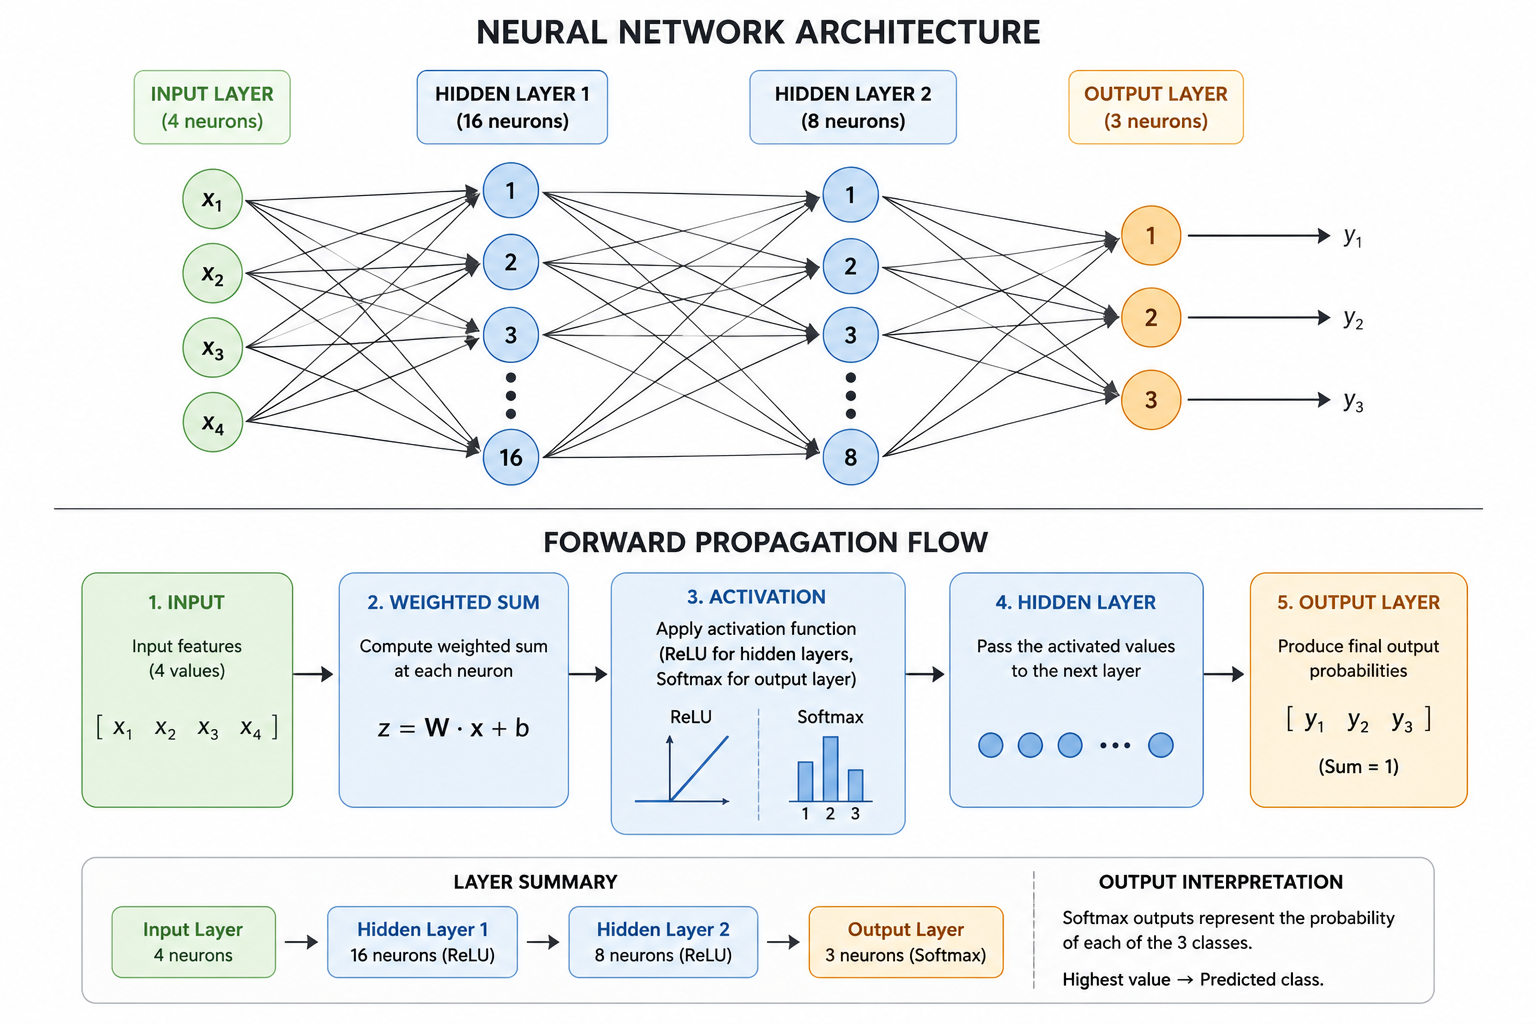

Compile Model

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

During training:

<ol>
<li>Forward Propagation
<li>Loss Calculation
<li>Backpropagation
<li>Weight Update
</ol>

![alt text](Compile.png)

Train Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3000 - loss: 1.3800 - val_accuracy: 0.2667 - val_loss: 1.4010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3000 - loss: 1.3510 - val_accuracy: 0.2667 - val_loss: 1.3725
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2917 - loss: 1.3269 - val_accuracy: 0.2333 - val_loss: 1.3453
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2833 - loss: 1.3032 - val_accuracy: 0.2000 - val_loss: 1.3202
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2750 - loss: 1.2816 - val_accuracy: 0.1667 - val_loss: 1.2969
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2750 - loss: 1.2624 - val_accuracy: 0.1667 - val_loss: 1.2754
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2750 - loss: 1.2441 - val_accuracy: 0.2333 - val_loss: 1.2557
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2750 - loss: 1.2261 - val_accuracy: 0.2333 - val_loss: 1.2377


Plot Accuracy

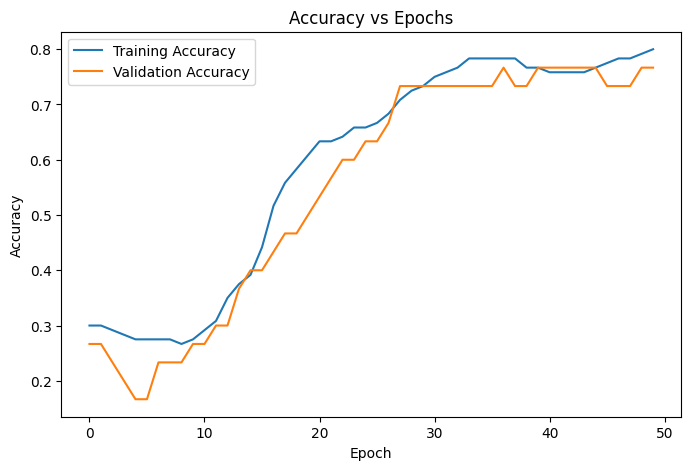

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epochs")

plt.legend()

plt.show()

Plot Loss

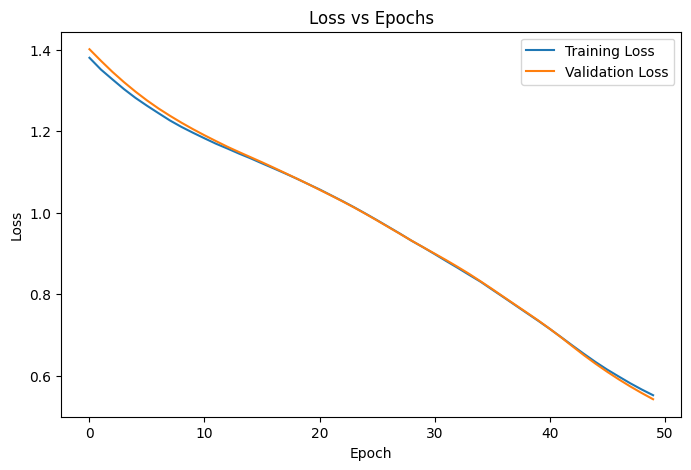

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.legend()

plt.show()

A good model typically shows:

<ul>
<li>Accuracy increasing over epochs.
<li>Loss decreasing over epochs.
</ul>

Model Evaluation

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)
print("Loss :",loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7667 - loss: 0.5423
Test Accuracy : 0.7666666507720947
Loss : 0.542343258857727


Prediction

In [29]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


Confusion Matrix

In [33]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  6,  5]])

Classification Report

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.57      0.89      0.70         9
           2       0.83      0.45      0.59        11

    accuracy                           0.77        30
   macro avg       0.80      0.78      0.76        30
weighted avg       0.81      0.77      0.76        30



### <b>Effect of Different Learning Rates</b>

<b>Note:</b> Creating a function for building a Neural Network & compling the perticular model with specific Learning Rate

In [36]:
def create_model(learning_rate):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Training the model at deferent Learning rate's

In [37]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

results = []

for lr in learning_rates:

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results.append((lr, acc))

d:\TY Sem-I\Deep Learning\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Display Results

In [38]:
for lr, acc in results:
    print(f"Learning Rate: {lr}  Accuracy: {acc:.4f}")

Learning Rate: 0.1  Accuracy: 1.0000
Learning Rate: 0.01  Accuracy: 1.0000
Learning Rate: 0.001  Accuracy: 0.9000
Learning Rate: 0.0001  Accuracy: 0.3667


Analysis

<li>0.1: May converge quickly but can overshoot the optimum and become unstable.
<li>0.01: Often learns faster while remaining stable.
<li>0.001: Common default for Adam; usually provides stable and high accuracy.
<li>0.0001: Very stable but learns slowly and may require more epochs.

### <b>Effect of Epochs</b>

In [40]:
epochs_list = [10, 30, 50, 100]

results = []

for e in epochs_list:

    model = create_model(0.001) # default learning rate  for Adam

    model.fit(
        X_train,
        y_train,
        epochs=e,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results.append((e, acc))

Display Results

In [41]:
for e, acc in results:
    print(f"Epochs: {e} Accuracy: {acc:.4f}")

Epochs: 10 Accuracy: 0.8667
Epochs: 30 Accuracy: 0.8333
Epochs: 50 Accuracy: 0.8667
Epochs: 100 Accuracy: 0.9667


Analysis

<li>10 epochs: The model may not have learned enough, resulting in lower accuracy (underfitting).
<li>30–50 epochs: Accuracy typically improves as the model learns better feature representations.
<li>100 epochs: The model may achieve slightly higher accuracy, but there is a possibility of overfitting if validation performance stops improving.

## Conclusion

- Implemented an MLP classifier using TensorFlow/Keras.
- Understood the role of forward propagation in generating predictions.
- Learned how backpropagation updates model weights using the calculated loss.
- Observed that learning rate significantly affects the speed and stability of training.
- Found that an appropriate number of epochs improves accuracy, while too few epochs can underfit and too many may lead to overfitting.
- Successfully evaluated the model using accuracy, confusion matrix, and classification report.